# 04 — Scorecard and Final Recommendation

This notebook consolidates the evidence from notebooks **02** and **03** into a final investment ranking for the €5,000 EDEN allocation.

It now includes:

1. the three fictional candidates: **Orion**, **Cleanergy**, and **NovaTerra**;
2. the public alternatives retained in the quantitative comparison from notebook 02;
3. the AHP-based portfolio-fit weighting method developed by the team;
4. a composite investment scorecard and sensitivity checks.

Important interpretation rule: the scorecard is a **decision-support model**, not a black-box buy signal. The final recommendation still requires analyst judgment, EDEN compliance review, and Q&A defensibility.


## Key Analytical Assumptions

The following assumptions define how the analysis was performed.

### 1. Candidate eligibility

Because Orion, Cleanergy, and NovaTerra are fictional companies, we assume they are valid EDEN investment candidates: public, OECD-listed, profitable, sufficiently liquid for a €5,000 position, compliant with the assessment restrictions, and meeting EDEN’s market-cap eligibility requirements.

For real public alternatives or benchmark candidates, we verify that the security satisfies EDEN’s market-cap constraint before treating it as investable.

Information not provided in the case — including valuation, balance sheet, free cash flow, liquidity, exact market capitalization, and exact listing venue — is treated as unavailable rather than estimated.

### 2. Return data

For the fictional candidates, we assume no dividends. Returns are calculated from the provided EOD price files.

For public ETFs and current portfolio holdings, returns are calculated using free public market data. Where adjusted-close data is used, returns may include dividend or distribution adjustments; where close prices are used, returns are price-return based.

### 3. Risk and performance metrics

Daily returns are the base input for the quantitative analysis. Annualized volatility assumes 252 trading days.

Sharpe ratios use one stated annual risk-free rate across the relevant comparison set. Maximum drawdown, VaR, CVaR, rolling volatility, beta, and correlation are calculated from historical return series.

### 4. Time-period treatment

Series with different start dates or missing observations are aligned on common dates before calculating correlations, betas, benchmark comparisons, or portfolio-level metrics.

Full-period metrics are calculated where available, and rolling or sub-period metrics are used to test whether results are stable across time.

### 5. Portfolio-fit and scorecard assumptions

Portfolio-fit analysis is performed incrementally by comparing the current portfolio with portfolios that add each candidate or alternative.

Qualitative portfolio-fit categories are converted into numerical scores using:

- Yes = 1.0
- Partial = 0.5
- No = 0.0

Each category is normalized onto a 0–100 scale so that the candidates can be compared consistently.

The final scorecard uses the following decision weights:

- Portfolio Fit: 25%
- Business Quality: 20%
- Growth: 15%
- Risk-Adjusted Performance: 15%
- Downside Risk: 10%
- EDEN Compliance: 10%
- Q&A Defensibility: 5%

These weights are analytical inputs, not statistical outputs. They reflect the assumption that this is a portfolio-allocation decision rather than a pure standalone stock-selection exercise. Portfolio fit receives the highest weight because the new €5,000 position must improve the existing EDEN portfolio, while business quality, growth, risk-adjusted performance, and downside risk ensure that the selected exposure is still investable on its own.

The scorecard is used as a structured comparison tool, not as an automated decision model. A higher score indicates stronger performance under the selected criteria and weights, but the ranking remains sensitive to the chosen weight assumptions.

### 6. PCA and category-correlation assumptions

PCA and category-correlation analysis are used only as diagnostics for the portfolio-fit scoring framework.

The category-correlation matrix is used to identify whether some scoring categories may overlap or double-count similar information. For example, sector diversification and structural theme exposure may partly capture the same underlying portfolio gap.

PCA is applied to the portfolio-fit category score matrix to assess which categories explain most of the variation across the candidates. Where PCA-based weights are calculated, they are used to support sensitivity analysis and weighting diagnostics, not to replace investment judgment.

Because the PCA is based on only three fictional candidates, the results are not treated as statistically robust. The output is useful for checking consistency and redundancy in the scoring framework, but it should not be interpreted as a precise estimate of the true importance of each category.

### 7. Fundamental and model limitations

Fundamental analysis uses only the case-provided business descriptions, client lists, supplier lists, competitive information, growth plans, and KPI tables.

Regression analysis is treated as exploratory because the KPI history contains only four annual observations. It is used to test whether selected KPIs appear directionally related to annual average price behavior, but it is not treated as causal evidence or as a forecasting model.

Monte Carlo simulation is also treated as exploratory. It uses historical return behavior as the base input for simulated portfolio outcomes. This assumes that the historical return distribution is a reasonable simplified input for illustrating possible future risk ranges.

The Monte Carlo simulation does not explicitly model transaction costs, taxes, liquidity constraints, valuation changes, structural regime shifts, or changes in company fundamentals. Therefore, its outputs are interpreted as risk illustrations rather than price targets or reliable forecasts.

In [1]:
# ============================================================
# Setup
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

# Detect project root by searching upward for data/ and outputs/
current_path = Path.cwd().resolve()
PROJECT_ROOT = None

for path in [current_path] + list(current_path.parents):
    if (path / "data").exists() and (path / "outputs").exists():
        PROJECT_ROOT = path
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not detect project root. Expected folders: data/ and outputs/. "
        "Run this notebook from inside the project folder."
    )

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUT_TABLES = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_CHARTS = PROJECT_ROOT / "outputs" / "charts"

for folder in [DATA_PROCESSED, OUTPUT_TABLES, OUTPUT_CHARTS]:
    folder.mkdir(parents=True, exist_ok=True)

FICTIONAL_CANDIDATES = ["Orion", "Cleanergy", "NovaTerra"]

print("Project root:", PROJECT_ROOT)
print("Output tables:", OUTPUT_TABLES)
print("Output charts:", OUTPUT_CHARTS)


Project root: C:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment
Output tables: C:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\tables
Output charts: C:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\charts


## 1. Load evidence from notebooks 02 and 03

Notebook 04 should consolidate prior outputs rather than recalculate the whole project. Before running this notebook, rerun:

- notebook **02** to export standalone candidate/public metrics;
- notebook **03** to export portfolio-impact and diversification metrics.


In [2]:
# ============================================================
# Load exported tables
# ============================================================

def load_csv(filename: str, required: bool = True) -> pd.DataFrame | None:
    """Load a CSV from outputs/tables with a clear error message."""
    path = OUTPUT_TABLES / filename
    if not path.exists():
        if required:
            raise FileNotFoundError(
                f"Missing required file: {path}\n"
                "Rerun the notebook that exports this file before continuing."
            )
        print(f"Optional table not found: {filename}")
        return None
    df = pd.read_csv(path)
    print(f"Loaded {filename}: {df.shape[0]} rows x {df.shape[1]} columns")
    return df

# Notebook 02 exports
candidate_metrics_raw = load_csv("candidate_metrics_raw.csv", required=True)
combined_metrics_raw = load_csv("02_candidate_vs_public_alternatives_metrics_raw.csv", required=True)
public_metrics_raw = load_csv("02_public_alternative_metrics_raw.csv", required=False)
investment_universe_screening = load_csv("02_investment_universe_screening.csv", required=False)

# Notebook 03 exports
scenario_incremental_impact = load_csv("03_scenario_incremental_portfolio_impact.csv", required=True)
scenario_asset_correlation = load_csv("03_scenario_asset_correlation_summary.csv", required=False)

print("\nCandidate metrics preview")
display(candidate_metrics_raw.head())

print("\nCombined candidate/public metrics preview")
display(combined_metrics_raw.head(10))

print("\nScenario incremental impact preview")
display(scenario_incremental_impact.head(10))


Loaded candidate_metrics_raw.csv: 3 rows x 15 columns
Loaded 02_candidate_vs_public_alternatives_metrics_raw.csv: 10 rows x 12 columns
Loaded 02_public_alternative_metrics_raw.csv: 7 rows x 11 columns
Loaded 02_investment_universe_screening.csv: 25 rows x 10 columns
Loaded 03_scenario_incremental_portfolio_impact.csv: 6 rows x 7 columns
Loaded 03_scenario_asset_correlation_summary.csv: 6 rows x 10 columns

Candidate metrics preview


,Candidate,Start Date,End Date,Observations,Cumulative Return,Ann. Return,Ann. Volatility,Sharpe Ratio,Max Drawdown,VaR 95%,VaR 95% €,CVaR 95%,CVaR 95% €,Skewness,Excess Kurtosis
0,Orion,2019-06-20,2026-02-25,1744,19.759640,0.550002,0.565781,0.919087,-0.627577,0.057765,288.825765,0.082326,411.628726,-0.342202,5.573486
1,Cleanergy,2018-01-02,2026-05-22,2188,0.862785,0.074275,0.459702,0.096313,-0.930443,0.048348,241.739693,0.055847,279.237428,-0.004552,-0.585546
2,NovaTerra,2012-08-31,2026-02-25,3518,0.041290,0.002902,0.318026,-0.085205,-0.874838,0.032928,164.638674,0.041191,205.957451,0.023569,0.033756



Combined candidate/public metrics preview


,Theme,Ticker,Type,Primary ETF Benchmark,Cumulative Return,Ann. Return,Ann. Volatility,Sharpe Ratio,Max Drawdown,VaR 95% €,CVaR 95% €,Observations
0,Semiconductors / Edge AI,Orion,Fictional Candidate,SMH,19.759640,0.550002,0.565781,0.919087,-0.627577,288.825765,411.628726,1744
1,Smart Grid / Energy Storage,Cleanergy,Fictional Candidate,GRID,0.862785,0.074275,0.459702,0.096313,-0.930443,241.739693,279.237428,2188
2,Precision Agriculture / AgTech,NovaTerra,Fictional Candidate,MOO,0.041290,0.002902,0.318026,-0.085205,-0.874838,164.638674,205.957451,3518
3,Semiconductors / Edge AI,SMH,ETF Alternative,SMH,7.241595,0.372927,0.357564,0.959064,-0.453026,174.786567,253.798376,1677
4,Smart Grid / Energy Storage,GRID,ETF Alternative,GRID,2.966414,0.230043,0.243347,0.822047,-0.405616,112.331523,172.875864,1677
5,Precision Agriculture / AgTech,MOO,ETF Alternative,MOO,0.505034,0.063358,0.201345,0.165677,-0.395154,87.611796,146.519113,1677
6,Semiconductors / Edge AI,CRUS,Stock Alternative,SMH,2.516724,0.208001,0.412121,0.431914,-0.468529,185.938376,287.936806,1677
7,Smart Grid / Energy Storage,ITRI,Stock Alternative,GRID,0.597909,0.072970,0.474540,0.090550,-0.652647,202.922443,340.236380,1677
8,Precision Agriculture / AgTech,TRMB,Stock Alternative,MOO,0.537788,0.066804,0.364881,0.100866,-0.573548,158.589915,265.525203,1677
9,Precision Agriculture / AgTech,AGCO,Stock Alternative,MOO,1.196448,0.125511,0.387671,0.246372,-0.540703,179.143241,275.393189,1677



Scenario incremental impact preview


,Asset Added,Asset Type,Change in Annualized Return,Change in Annualized Volatility,Change in Sharpe Ratio,Change in Max Drawdown,Drawdown Impact
0,Orion,Fictional Candidate,0.053617,0.029248,0.166434,-0.025193,Worsens
1,Cleanergy,Fictional Candidate,-0.001653,-0.014386,0.041141,-0.053960,Worsens
2,NovaTerra,Fictional Candidate,0.006440,-0.015100,0.091108,0.013284,Improves
3,SMH,Public Alternative ETF,0.028728,0.008034,0.122746,0.003616,Improves
4,GRID,Public Alternative ETF,0.010160,0.000968,0.051118,-0.008432,Worsens
5,MOO,Public Alternative ETF,-0.011335,-0.004796,-0.046419,-0.000782,Worsens


## 2. Define the investable ranking universe

The ranking universe is taken from notebook 02's combined candidate/public table. This means public alternatives enter the final ranking only if they were retained in the quant comparison.

By design, this prevents qualitative-only comparables or public stocks that failed the market-cap screen from entering the final recommendation model.


In [3]:
# ============================================================
# Standardize metric table and define universe
# ============================================================

def standardize_metrics_table(df: pd.DataFrame) -> pd.DataFrame:
    """Standardize candidate/public metric columns for scoring."""
    out = df.copy()
    rename_map = {
        "Candidate": "Ticker",
        "Sharpe": "Sharpe Ratio",
        "Obs.": "Observations",
        "Annualized Return": "Ann. Return",
        "Annualized Volatility": "Ann. Volatility",
    }
    out = out.rename(columns={k: v for k, v in rename_map.items() if k in out.columns})
    if "Ticker" not in out.columns:
        raise ValueError("Metrics table must contain either 'Ticker' or 'Candidate'.")
    if "Type" not in out.columns:
        out["Type"] = out["Ticker"].apply(
            lambda x: "Fictional Candidate" if x in FICTIONAL_CANDIDATES else "Public Alternative"
        )
    return out

metrics = standardize_metrics_table(combined_metrics_raw)
metrics["Ticker"] = metrics["Ticker"].astype(str)

# Keep one row per ticker. If duplicates exist, keep the first occurrence exported by notebook 02.
metrics = metrics.drop_duplicates(subset="Ticker", keep="first").reset_index(drop=True)

# Main universe: fictional candidates + public alternatives retained in notebook 02.
UNIVERSE = metrics["Ticker"].tolist()
PUBLIC_ALTERNATIVES = [ticker for ticker in UNIVERSE if ticker not in FICTIONAL_CANDIDATES]

print("Ranking universe:", UNIVERSE)
print("Fictional candidates:", FICTIONAL_CANDIDATES)
print("Public alternatives retained from notebook 02:", PUBLIC_ALTERNATIVES)

display(metrics[[c for c in ["Ticker", "Type", "Theme", "Primary ETF Benchmark", "Ann. Return", "Ann. Volatility", "Sharpe Ratio", "Max Drawdown", "CVaR 95% €"] if c in metrics.columns]])


Ranking universe: ['Orion', 'Cleanergy', 'NovaTerra', 'SMH', 'GRID', 'MOO', 'CRUS', 'ITRI', 'TRMB', 'AGCO']
Fictional candidates: ['Orion', 'Cleanergy', 'NovaTerra']
Public alternatives retained from notebook 02: ['SMH', 'GRID', 'MOO', 'CRUS', 'ITRI', 'TRMB', 'AGCO']


,Ticker,Type,Theme,Primary ETF Benchmark,Ann. Return,Ann. Volatility,Sharpe Ratio,Max Drawdown,CVaR 95% €
0,Orion,Fictional Candidate,Semiconductors / Edge AI,SMH,0.550002,0.565781,0.919087,-0.627577,411.628726
1,Cleanergy,Fictional Candidate,Smart Grid / Energy Storage,GRID,0.074275,0.459702,0.096313,-0.930443,279.237428
2,NovaTerra,Fictional Candidate,Precision Agriculture / AgTech,MOO,0.002902,0.318026,-0.085205,-0.874838,205.957451
3,SMH,ETF Alternative,Semiconductors / Edge AI,SMH,0.372927,0.357564,0.959064,-0.453026,253.798376
4,GRID,ETF Alternative,Smart Grid / Energy Storage,GRID,0.230043,0.243347,0.822047,-0.405616,172.875864
5,MOO,ETF Alternative,Precision Agriculture / AgTech,MOO,0.063358,0.201345,0.165677,-0.395154,146.519113
6,CRUS,Stock Alternative,Semiconductors / Edge AI,SMH,0.208001,0.412121,0.431914,-0.468529,287.936806
7,ITRI,Stock Alternative,Smart Grid / Energy Storage,GRID,0.072970,0.474540,0.090550,-0.652647,340.236380
8,TRMB,Stock Alternative,Precision Agriculture / AgTech,MOO,0.066804,0.364881,0.100866,-0.573548,265.525203
9,AGCO,Stock Alternative,Precision Agriculture / AgTech,MOO,0.125511,0.387671,0.246372,-0.540703,275.393189


## 3. AHP-based portfolio-fit model

This section now imports the team’s final AHP files directly rather than reconstructing the weights inside notebook 04. This is safer for auditability because the notebook uses exactly the same files produced by the portfolio-fit workstream:

- `portfolio_fit_weights.xlsx`
- `ahp_pairwise_matrix.xlsx`
- `category_scores.xlsx`
- `final_portfolio_fit_scores.xlsx`

The fictional candidates therefore use the team’s final category scores and AHP weights. Public alternatives are added separately using explicit analyst judgment category scores, then evaluated using the same AHP weights so they can be compared in the final ranking.


In [4]:
# ============================================================
# Load team AHP portfolio-fit files directly
# ============================================================
# This cell reads the final files produced by the portfolio-fit
# workstream where available. The only required files are:
#   - portfolio_fit_weights.xlsx
#   - category_scores.xlsx
#
# final_portfolio_fit_scores.xlsx and ahp_pairwise_matrix.xlsx are optional:
# the notebook can recompute final portfolio-fit scores from category scores
# and weights if the final output file is not present locally.
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

PORTFOLIO_FIT_CRITERIA = [
    "Sector Diversification",
    "Growth Profile",
    "Geographic Diversification",
    "Structural Theme Exposure",
    "Revenue Quality",
]

if "FICTIONAL_CANDIDATES" not in globals():
    FICTIONAL_CANDIDATES = ["Orion", "Cleanergy", "NovaTerra"]


def find_input_file(filename: str, required: bool = True) -> Path | None:
    """
    Search common project folders for an input file.

    For local use, place AHP Excel files in one of:
      - data/raw/
      - data/
      - outputs/tables/
      - project root
    """

    candidate_dirs = []

    for var_name in ["DATA_RAW", "DATA_PROCESSED", "OUTPUT_TABLES", "PROJECT_ROOT"]:
        if var_name in globals():
            candidate_dirs.append(Path(globals()[var_name]))

    candidate_dirs.extend([
        Path.cwd(),
        Path.cwd() / "data",
        Path.cwd() / "data" / "raw",
        Path.cwd() / "outputs" / "tables",
        Path("/mnt/data"),  # useful only in the ChatGPT sandbox
    ])

    search_dirs = []
    for folder in candidate_dirs:
        if folder not in search_dirs:
            search_dirs.append(folder)

    for folder in search_dirs:
        candidate_path = folder / filename
        if candidate_path.exists():
            return candidate_path

    if required:
        searched = "\n".join(str(folder / filename) for folder in search_dirs)
        raise FileNotFoundError(
            f"Could not find required input file: {filename}\n"
            f"Searched:\n{searched}\n\n"
            "Place the AHP Excel files in data/raw/, data/, outputs/tables/, "
            "or the project root, then rerun this cell."
        )

    return None


def read_indexed_excel(path: Path) -> pd.DataFrame:
    """
    Read an Excel file where the first column may be an unnamed index column.

    This handles files exported with DataFrame.to_excel(), where the index often
    appears as 'Unnamed: 0' when read back without index_col=0.
    """

    df = pd.read_excel(path)
    df.columns = df.columns.astype(str).str.strip()

    first_col = df.columns[0]
    if str(first_col).startswith("Unnamed") or first_col in ["index", "Company", "Candidate", "Ticker"]:
        df = df.set_index(first_col)

    df.index = df.index.astype(str).str.strip()
    df.columns = df.columns.astype(str).str.strip()

    return df


# ============================================================
# Locate files
# ============================================================

team_weights_path = find_input_file("portfolio_fit_weights.xlsx", required=True)
team_category_scores_path = find_input_file("category_scores.xlsx", required=True)
team_matrix_path = find_input_file("ahp_pairwise_matrix.xlsx", required=False)
team_final_scores_path = find_input_file("final_portfolio_fit_scores.xlsx", required=False)


# ============================================================
# Load required files
# ============================================================

portfolio_fit_weights_df = pd.read_excel(team_weights_path)
portfolio_fit_weights_df.columns = portfolio_fit_weights_df.columns.astype(str).str.strip()

team_category_scores_raw = read_indexed_excel(team_category_scores_path)


# ============================================================
# Validate and clean AHP weights
# ============================================================

required_weight_cols = {"Category", "Weight"}

if not required_weight_cols.issubset(portfolio_fit_weights_df.columns):
    raise ValueError(
        f"portfolio_fit_weights.xlsx must contain columns {required_weight_cols}. "
        f"Found: {list(portfolio_fit_weights_df.columns)}"
    )

portfolio_fit_weights_df["Category"] = (
    portfolio_fit_weights_df["Category"]
    .astype(str)
    .str.strip()
)

portfolio_fit_weights = (
    portfolio_fit_weights_df
    .set_index("Category")["Weight"]
    .astype(float)
    .reindex(PORTFOLIO_FIT_CRITERIA)
)

if portfolio_fit_weights.isna().any():
    missing = portfolio_fit_weights[portfolio_fit_weights.isna()].index.tolist()
    raise ValueError(f"Missing AHP weights for categories: {missing}")

portfolio_fit_weights = portfolio_fit_weights / portfolio_fit_weights.sum()


# ============================================================
# Validate and clean category scores
# ============================================================

missing_score_cols = [
    c for c in PORTFOLIO_FIT_CRITERIA
    if c not in team_category_scores_raw.columns
]

if missing_score_cols:
    raise ValueError(
        f"category_scores.xlsx is missing columns: {missing_score_cols}. "
        f"Available columns: {list(team_category_scores_raw.columns)}"
    )

missing_fictional_rows = [
    c for c in FICTIONAL_CANDIDATES
    if c not in team_category_scores_raw.index
]

if missing_fictional_rows:
    raise ValueError(
        f"category_scores.xlsx is missing fictional candidates: {missing_fictional_rows}. "
        f"Available rows: {list(team_category_scores_raw.index)}"
    )

team_category_scores = (
    team_category_scores_raw
    .loc[FICTIONAL_CANDIDATES, PORTFOLIO_FIT_CRITERIA]
    .astype(float)
)


# ============================================================
# Optional pairwise matrix and AHP consistency ratio
# ============================================================

def compute_ahp_consistency_ratio(matrix_df: pd.DataFrame) -> float:
    """Compute AHP consistency ratio from an imported pairwise matrix."""

    matrix_df = matrix_df.copy()
    matrix_df.index = matrix_df.index.astype(str).str.strip()
    matrix_df.columns = matrix_df.columns.astype(str).str.strip()

    missing_rows = [c for c in PORTFOLIO_FIT_CRITERIA if c not in matrix_df.index]
    missing_cols = [c for c in PORTFOLIO_FIT_CRITERIA if c not in matrix_df.columns]

    if missing_rows or missing_cols:
        raise ValueError(
            f"AHP matrix missing rows {missing_rows} or columns {missing_cols}."
        )

    matrix = (
        matrix_df
        .loc[PORTFOLIO_FIT_CRITERIA, PORTFOLIO_FIT_CRITERIA]
        .astype(float)
        .values
    )

    n = matrix.shape[0]
    eigenvalues, _ = np.linalg.eig(matrix)
    lambda_max = eigenvalues.real.max()
    ci = (lambda_max - n) / (n - 1)

    ri_table = {
        1: 0.00, 2: 0.00, 3: 0.58, 4: 0.90, 5: 1.12,
        6: 1.24, 7: 1.32, 8: 1.41, 9: 1.45, 10: 1.49,
    }

    ri = ri_table.get(n, 1.49)

    return ci / ri if ri != 0 else 0.0


if team_matrix_path is not None:
    ahp_matrix_df = read_indexed_excel(team_matrix_path)
    try:
        consistency_ratio = compute_ahp_consistency_ratio(ahp_matrix_df)
    except Exception as exc:
        consistency_ratio = np.nan
        print(f"Could not compute AHP consistency ratio from imported matrix: {exc}")
else:
    ahp_matrix_df = pd.DataFrame()
    consistency_ratio = np.nan
    print("Optional file not found: ahp_pairwise_matrix.xlsx. Continuing without consistency-ratio diagnostic.")


# ============================================================
# Recompute final fictional portfolio-fit scores from required files
# ============================================================

team_final_portfolio_fit_scores = team_category_scores.copy()
team_final_portfolio_fit_scores["Portfolio Fit Score"] = (
    team_category_scores
    .mul(portfolio_fit_weights, axis=1)
    .sum(axis=1)
)

# Optional cross-check against final_portfolio_fit_scores.xlsx if present.
if team_final_scores_path is not None:
    imported_final_scores = read_indexed_excel(team_final_scores_path)
    imported_final_scores.columns = imported_final_scores.columns.astype(str).str.strip()

    if "Portfolio Fit Score" in imported_final_scores.columns:
        imported_final = (
            imported_final_scores
            .loc[FICTIONAL_CANDIDATES, "Portfolio Fit Score"]
            .astype(float)
            .rename("Imported Portfolio Fit Score")
        )

        recomputed_final = (
            team_final_portfolio_fit_scores["Portfolio Fit Score"]
            .rename("Recomputed Portfolio Fit Score")
        )

        portfolio_fit_crosscheck = pd.concat(
            [imported_final, recomputed_final],
            axis=1
        )
        portfolio_fit_crosscheck["Difference"] = (
            portfolio_fit_crosscheck["Recomputed Portfolio Fit Score"]
            - portfolio_fit_crosscheck["Imported Portfolio Fit Score"]
        )
    else:
        portfolio_fit_crosscheck = pd.DataFrame()
        print("final_portfolio_fit_scores.xlsx found, but no 'Portfolio Fit Score' column. Skipping cross-check.")
else:
    portfolio_fit_crosscheck = pd.DataFrame()
    print("Optional file not found: final_portfolio_fit_scores.xlsx. Recomputed scores will be used.")


# ============================================================
# Display diagnostics
# ============================================================

print("Loaded team AHP files:")
print("Weights:", team_weights_path)
print("Category scores:", team_category_scores_path)
print("Pairwise matrix:", team_matrix_path if team_matrix_path is not None else "not available")
print("Final portfolio-fit scores:", team_final_scores_path if team_final_scores_path is not None else "recomputed")

print(
    "\nAHP consistency ratio:",
    round(consistency_ratio, 4) if pd.notna(consistency_ratio) else "not available"
)

if pd.notna(consistency_ratio):
    if consistency_ratio > 0.10:
        print("Warning: AHP consistency ratio is above 0.10. Review pairwise judgments.")
    else:
        print("AHP consistency is acceptable under the usual CR < 0.10 rule of thumb.")

print("\nImported portfolio-fit weights")
display(
    (portfolio_fit_weights * 100)
    .round(2)
    .to_frame("Weight %")
    .sort_values("Weight %", ascending=False)
)

print("\nImported fictional-company category scores")
display(team_category_scores.round(2))

print("\nRecomputed fictional-company final portfolio-fit scores")
display(team_final_portfolio_fit_scores.round(2))

if not portfolio_fit_crosscheck.empty:
    print("\nPortfolio-fit score cross-check")
    display(portfolio_fit_crosscheck.round(4))


Optional file not found: ahp_pairwise_matrix.xlsx. Continuing without consistency-ratio diagnostic.
Optional file not found: final_portfolio_fit_scores.xlsx. Recomputed scores will be used.
Loaded team AHP files:
Weights: C:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\data\raw\portfolio_fit_weights.xlsx
Category scores: C:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\data\raw\category_scores.xlsx
Pairwise matrix: not available
Final portfolio-fit scores: recomputed

AHP consistency ratio: not available

Imported portfolio-fit weights


,Weight %
Category,
Sector Diversification,41.85
Structural Theme Exposure,26.25
Growth Profile,15.99
Revenue Quality,9.73
Geographic Diversification,6.18



Imported fictional-company category scores


,Sector Diversification,Growth Profile,Geographic Diversification,Structural Theme Exposure,Revenue Quality
Unnamed: 0,,,,,
Orion,0.00,100.00,50.00,50.00,50.00
Cleanergy,100.00,100.00,33.33,100.00,83.33
NovaTerra,83.33,66.67,100.00,83.33,100.00



Recomputed fictional-company final portfolio-fit scores


,Sector Diversification,Growth Profile,Geographic Diversification,Structural Theme Exposure,Revenue Quality,Portfolio Fit Score
Unnamed: 0,,,,,,
Orion,0.00,100.00,50.00,50.00,50.00,37.07
Cleanergy,100.00,100.00,33.33,100.00,83.33,94.26
NovaTerra,83.33,66.67,100.00,83.33,100.00,83.32


In [5]:
# ============================================================
# Portfolio-fit category scores for fictional and public alternatives
# ============================================================
# Fictional candidates are imported directly from category_scores.xlsx.
# Public alternatives are judgmental proxy scores added by the analyst,
# then evaluated using the same imported AHP weights.
#
# Scale: 0-100, matching the team portfolio-fit scoring framework.
# ETFs are scored as diversified thematic exposures rather than as
# single operating companies.
# ============================================================

# Public alternatives considered in notebook 02.
# Review these assumptions before final submission.
public_portfolio_fit_category_score_inputs = pd.DataFrame.from_dict({
    # Public ETF alternatives
    "SMH": {
        "Sector Diversification": 0.00,
        "Growth Profile": 83.33,
        "Geographic Diversification": 50.00,
        "Structural Theme Exposure": 50.00,
        "Revenue Quality": 83.33,
    },
    "GRID": {
        "Sector Diversification": 100.00,
        "Growth Profile": 66.67,
        "Geographic Diversification": 50.00,
        "Structural Theme Exposure": 100.00,
        "Revenue Quality": 83.33,
    },
    "MOO": {
        "Sector Diversification": 83.33,
        "Growth Profile": 50.00,
        "Geographic Diversification": 83.33,
        "Structural Theme Exposure": 66.67,
        "Revenue Quality": 83.33,
    },

    # Public stock alternatives considered in notebook 02
    "CRUS": {
        "Sector Diversification": 0.00,
        "Growth Profile": 66.67,
        "Geographic Diversification": 50.00,
        "Structural Theme Exposure": 50.00,
        "Revenue Quality": 66.67,
    },
    "ITRI": {
        "Sector Diversification": 100.00,
        "Growth Profile": 66.67,
        "Geographic Diversification": 50.00,
        "Structural Theme Exposure": 100.00,
        "Revenue Quality": 83.33,
    },
    "TRMB": {
        "Sector Diversification": 83.33,
        "Growth Profile": 66.67,
        "Geographic Diversification": 83.33,
        "Structural Theme Exposure": 66.67,
        "Revenue Quality": 83.33,
    },
    "AGCO": {
        "Sector Diversification": 83.33,
        "Growth Profile": 50.00,
        "Geographic Diversification": 83.33,
        "Structural Theme Exposure": 50.00,
        "Revenue Quality": 66.67,
    },
}, orient="index")

# Start with the imported team scores for the fictional candidates.
portfolio_fit_category_scores = pd.DataFrame(index=UNIVERSE, columns=PORTFOLIO_FIT_CRITERIA, dtype=float)
fictional_in_universe = [asset for asset in FICTIONAL_CANDIDATES if asset in UNIVERSE]
portfolio_fit_category_scores.loc[fictional_in_universe, PORTFOLIO_FIT_CRITERIA] = team_category_scores.loc[
    fictional_in_universe,
    PORTFOLIO_FIT_CRITERIA,
]

# Add public-alternative scores for the public assets retained by notebook 02.
public_in_universe = [asset for asset in PUBLIC_ALTERNATIVES if asset in public_portfolio_fit_category_score_inputs.index]
portfolio_fit_category_scores.loc[public_in_universe, PORTFOLIO_FIT_CRITERIA] = public_portfolio_fit_category_score_inputs.loc[
    public_in_universe,
    PORTFOLIO_FIT_CRITERIA,
]

# If a public asset appears in notebook 02 but was not manually scored above, assign neutral scores and flag it.
missing_pf_scores = portfolio_fit_category_scores[portfolio_fit_category_scores.isna().any(axis=1)].index.tolist()
if missing_pf_scores:
    print("Warning: missing portfolio-fit category scores for:", missing_pf_scores)
    print("Assigning neutral 50/100 scores. Replace these with analyst judgments before final submission.")
    portfolio_fit_category_scores = portfolio_fit_category_scores.fillna(50.00)

# Calculate AHP-weighted portfolio-fit score and convert to the 1-5 scorecard scale.
portfolio_fit_scores_100 = portfolio_fit_category_scores.mul(portfolio_fit_weights, axis=1).sum(axis=1)
portfolio_fit_scores_1_to_5 = 1 + 4 * (portfolio_fit_scores_100 / 100)

portfolio_fit_model = portfolio_fit_category_scores.copy()
portfolio_fit_model["Portfolio Fit Score / 100"] = portfolio_fit_scores_100
portfolio_fit_model["Portfolio Fit Score / 5"] = portfolio_fit_scores_1_to_5
portfolio_fit_model = portfolio_fit_model.sort_values("Portfolio Fit Score / 100", ascending=False)

# Cross-check the imported final fictional-company scores.
if "Portfolio Fit Score" in team_final_portfolio_fit_scores.columns:
    imported_final = team_final_portfolio_fit_scores["Portfolio Fit Score"].astype(float)
    recomputed_final = portfolio_fit_scores_100.reindex(imported_final.index.intersection(portfolio_fit_scores_100.index))
    imported_final = imported_final.reindex(recomputed_final.index)
    max_abs_diff = (recomputed_final.round(2) - imported_final.round(2)).abs().max()
    print(f"Max absolute difference vs imported final fictional scores, rounded to 2 decimals: {max_abs_diff:.4f}")
    if max_abs_diff > 0.01:
        print("Warning: recomputed fictional portfolio-fit scores do not match final_portfolio_fit_scores.xlsx. Review inputs.")

print("Portfolio-fit model ranking")
display(portfolio_fit_model.round(2))


Max absolute difference vs imported final fictional scores, rounded to 2 decimals: 0.0000
Portfolio-fit model ranking


,Sector Diversification,Growth Profile,Geographic Diversification,Structural Theme Exposure,Revenue Quality,Portfolio Fit Score / 100,Portfolio Fit Score / 5
Cleanergy,100.00,100.00,33.33,100.00,83.33,94.26,4.77
GRID,100.00,66.67,50.00,100.00,83.33,89.96,4.60
ITRI,100.00,66.67,50.00,100.00,83.33,89.96,4.60
NovaTerra,83.33,66.67,100.00,83.33,100.00,83.32,4.33
TRMB,83.33,66.67,83.33,66.67,83.33,76.29,4.05
MOO,83.33,50.00,83.33,66.67,83.33,73.63,3.95
AGCO,83.33,50.00,83.33,50.00,66.67,67.63,3.71
SMH,0.00,83.33,50.00,50.00,83.33,37.64,2.51
Orion,0.00,100.00,50.00,50.00,50.00,37.07,2.48
CRUS,0.00,66.67,50.00,50.00,66.67,33.36,2.33


## 4. Analyst judgment scores

These are deliberately explicit and editable. The scorecard needs qualitative judgment for business quality, growth, compliance, and Q&A defensibility because not all public alternatives have directly comparable fictional-company KPIs.

Scale: **1 = weak**, **3 = acceptable**, **5 = strong**.


In [6]:
# ============================================================
# Analyst judgment scores, editable by the team
# ============================================================

judgment_score_inputs = pd.DataFrame.from_dict({
    # Fictional candidates
    "Orion": {
        "Business Quality": 3.5,     # strong technology story, but customer concentration, foundry dependence, and margin compression
        "Growth": 4.5,               # high unit growth and software mix expansion
        "EDEN Compliance": 5.0,      # advisor assumption: fictional stocks are valid EDEN targets
        "Q&A Defensibility": 3.5,    # challenged by ASML overlap and margin compression
    },
    "Cleanergy": {
        "Business Quality": 4.0,     # recurring lease/ARR model, improving margins, but supplier dependence
        "Growth": 4.0,               # strong GWh/ARR expansion and energy-transition theme
        "EDEN Compliance": 5.0,
        "Q&A Defensibility": 4.0,    # strongest portfolio-gap story, but drawdown must be defended
    },
    "NovaTerra": {
        "Business Quality": 3.5,     # high subscription mix and data/AI story, but revenue per acre pressure
        "Growth": 3.5,               # acres monitored and AI accuracy improving, but pricing power is less clear
        "EDEN Compliance": 4.5,      # OECD listing assumed; emerging-market expansion should be framed as operating exposure, not security exposure
        "Q&A Defensibility": 3.0,    # weaker link to current portfolio gap and compliance narrative needs care
    },

    # ETF alternatives
    "SMH": {
        "Business Quality": 4.5,     # diversified basket of high-quality semiconductor names
        "Growth": 4.0,
        "EDEN Compliance": 5.0,
        "Q&A Defensibility": 4.0,    # defensible ETF, but duplicates ASML/semiconductor exposure
    },
    "GRID": {
        "Business Quality": 4.5,     # diversified smart-grid/infrastructure exposure
        "Growth": 3.5,
        "EDEN Compliance": 5.0,
        "Q&A Defensibility": 4.5,    # strongest public ETF challenge to Cleanergy
    },
    "MOO": {
        "Business Quality": 4.0,     # diversified agribusiness exposure, less pure AI/agtech
        "Growth": 2.5,
        "EDEN Compliance": 5.0,
        "Q&A Defensibility": 4.0,
    },

    # Public stock alternatives
    "CRUS": {
        "Business Quality": 3.5,
        "Growth": 3.0,
        "EDEN Compliance": 4.0,      # depends on final profitability/OECD/market-cap screen from notebook 02
        "Q&A Defensibility": 3.0,
    },
    "ITRI": {
        "Business Quality": 4.0,
        "Growth": 3.5,
        "EDEN Compliance": 4.0,
        "Q&A Defensibility": 4.0,
    },
    "TRMB": {
        "Business Quality": 4.0,
        "Growth": 3.5,
        "EDEN Compliance": 4.0,
        "Q&A Defensibility": 3.5,
    },
    "AGCO": {
        "Business Quality": 3.5,
        "Growth": 2.5,
        "EDEN Compliance": 4.0,
        "Q&A Defensibility": 3.5,
    },
}, orient="index")

judgment_scores = judgment_score_inputs.reindex(UNIVERSE)
missing_judgment_scores = judgment_scores[judgment_scores.isna().any(axis=1)].index.tolist()
if missing_judgment_scores:
    print("Warning: missing judgment scores for:", missing_judgment_scores)
    print("Assigning neutral 3/5 scores. Replace before final submission.")
    judgment_scores = judgment_scores.fillna(3.0)

# Optional compliance override from notebook 02 screening table.
# If notebook 02 marks a public asset as excluded from the main quant comparison, it should not be in UNIVERSE.
# This block only makes the compliance rationale visible.
if investment_universe_screening is not None and "Ticker" in investment_universe_screening.columns:
    screening_view = investment_universe_screening[
        investment_universe_screening["Ticker"].astype(str).isin(UNIVERSE)
    ].copy()
    print("Investment-universe screening rows for ranked assets")
    display(screening_view)

print("Analyst judgment scores")
display(judgment_scores)


Investment-universe screening rows for ranked assets


,Ticker,Type,Theme,EDEN Compliance View,Market-Cap Screen Required?,Market-Cap Eligible?,Market Cap $bn,Role in Analysis,Included in Main Quant Comparison?,Reason / Caveat
0,SMH,ETF,Orion benchmark: semiconductors / AI chips,Likely compliant as public ETF; still check li...,False,N/A - ETF benchmark,NaN,Full quant benchmark and possible diversified ...,True,ETF alternative to fictional single-name exposure
1,GRID,ETF,Cleanergy benchmark: smart-grid infrastructure,Likely compliant as public ETF; still check li...,False,N/A - ETF benchmark,NaN,Full quant benchmark and possible diversified ...,True,ETF alternative to fictional single-name exposure
2,MOO,ETF,NovaTerra benchmark: agribusiness,Likely compliant as public ETF; still check li...,False,N/A - ETF benchmark,NaN,Full quant benchmark and possible diversified ...,True,ETF alternative to fictional single-name exposure
3,CRUS,Stock,Orion alternative: profitable mid-cap fabless ...,"Requires profitability, OECD-listing, and norm...",True,True,8.825956,Full quant comparison and possible public stoc...,True,Passes market-cap screen; still requires profi...
4,ITRI,Stock,Cleanergy alternative: smart-grid / utility in...,"Requires profitability, OECD-listing, and norm...",True,True,3.611440,Full quant comparison and possible public stoc...,True,Passes market-cap screen; still requires profi...
5,TRMB,Stock,"NovaTerra alternative: positioning, software, ...","Requires profitability, OECD-listing, and norm...",True,True,13.194112,Full quant comparison and possible public stoc...,True,Passes market-cap screen; still requires profi...
6,AGCO,Stock,NovaTerra alternative: agricultural equipment ...,"Requires profitability, OECD-listing, and norm...",True,True,8.750570,Full quant comparison and possible public stoc...,True,Passes market-cap screen; still requires profi...


Analyst judgment scores


,Business Quality,Growth,EDEN Compliance,Q&A Defensibility
Orion,3.5,4.5,5.0,3.5
Cleanergy,4.0,4.0,5.0,4.0
NovaTerra,3.5,3.5,4.5,3.0
SMH,4.5,4.0,5.0,4.0
GRID,4.5,3.5,5.0,4.5
MOO,4.0,2.5,5.0,4.0
CRUS,3.5,3.0,4.0,3.0
ITRI,4.0,3.5,4.0,4.0
TRMB,4.0,3.5,4.0,3.5
AGCO,3.5,2.5,4.0,3.5


## 5. Quantitative component scores

Risk-adjusted performance and downside risk come directly from notebook 02's exported metrics.

- **Risk-Adjusted Performance** is based on Sharpe Ratio.
- **Downside Risk** rewards lower drawdown and lower CVaR where available.

All component scores are converted to a common **1–5** scale.


In [7]:
# ============================================================
# Quantitative scoring helpers
# ============================================================

def rank_to_score(series: pd.Series, higher_is_better: bool = True) -> pd.Series:
    """
    Convert a numeric series into a 1-5 percentile score.

    The best observation receives 5 and the worst receives 1.
    """
    s = pd.to_numeric(series, errors="coerce")

    if s.notna().sum() <= 1:
        return pd.Series(3.0, index=series.index)

    # If higher is better, the highest value should receive pct-rank 1.0.
    # If lower is better, the lowest value should receive pct-rank 1.0.
    ranks = s.rank(
        pct=True,
        ascending=higher_is_better,
        method="average"
    )

    scores = 1 + 4 * ranks

    return scores.fillna(3.0).clip(lower=1, upper=5)


metrics_indexed = metrics.set_index("Ticker")
metrics_indexed.index = metrics_indexed.index.astype(str).str.strip()
metrics_indexed.columns = metrics_indexed.columns.astype(str).str.strip()

# Risk-adjusted performance: use Sharpe if present; otherwise use return / volatility.
if "Sharpe Ratio" in metrics_indexed.columns:
    sharpe_series = metrics_indexed["Sharpe Ratio"]
else:
    required_for_proxy = {"Ann. Return", "Ann. Volatility"}
    if not required_for_proxy.issubset(metrics_indexed.columns):
        raise ValueError(
            "Cannot compute risk-adjusted score. Need 'Sharpe Ratio' or both "
            "'Ann. Return' and 'Ann. Volatility'. "
            f"Available columns: {list(metrics_indexed.columns)}"
        )
    sharpe_series = metrics_indexed["Ann. Return"] / metrics_indexed["Ann. Volatility"]

risk_adjusted_score = rank_to_score(
    sharpe_series.reindex(UNIVERSE),
    higher_is_better=True
)

# Downside risk: average max-drawdown rank and CVaR rank if both are available.
downside_components = []

if "Max Drawdown" in metrics_indexed.columns:
    max_dd = pd.to_numeric(metrics_indexed["Max Drawdown"].reindex(UNIVERSE), errors="coerce")

    # If drawdown is stored as negative returns, higher is better
    # because -20% is better than -60%. If stored as positive loss
    # magnitude, lower is better.
    max_dd_higher_is_better = max_dd.dropna().lt(0).any()

    downside_components.append(
        rank_to_score(max_dd, higher_is_better=max_dd_higher_is_better)
    )

if "CVaR 95% €" in metrics_indexed.columns:
    # CVaR in euros is usually a positive expected loss; lower is better.
    downside_components.append(
        rank_to_score(metrics_indexed["CVaR 95% €"].reindex(UNIVERSE), higher_is_better=False)
    )
elif "CVaR 95%" in metrics_indexed.columns:
    cvar = pd.to_numeric(metrics_indexed["CVaR 95%"].reindex(UNIVERSE), errors="coerce")
    # If CVaR is negative return, higher is better. If positive loss, lower is better.
    cvar_higher_is_better = cvar.dropna().lt(0).any()
    downside_components.append(
        rank_to_score(cvar, higher_is_better=cvar_higher_is_better)
    )

if downside_components:
    downside_risk_score = pd.concat(downside_components, axis=1).mean(axis=1)
else:
    downside_risk_score = pd.Series(3.0, index=UNIVERSE)

quant_scores = pd.DataFrame({
    "Risk-Adjusted Performance": risk_adjusted_score,
    "Downside Risk": downside_risk_score,
})

print("Quantitative component scores")
display(quant_scores.round(2))

print("Underlying risk/return metrics")
display(
    metrics_indexed
    .reindex(UNIVERSE)
    [[c for c in ["Type", "Theme", "Ann. Return", "Ann. Volatility", "Sharpe Ratio", "Max Drawdown", "CVaR 95% €", "CVaR 95%"] if c in metrics_indexed.columns]]
)


Quantitative component scores


,Risk-Adjusted Performance,Downside Risk
Ticker,,
Orion,4.6,2.0
Cleanergy,2.2,2.0
NovaTerra,1.4,3.0
SMH,5.0,4.0
GRID,4.2,4.6
MOO,3.0,5.0
CRUS,3.8,3.0
ITRI,1.8,2.0
TRMB,2.6,3.2


Underlying risk/return metrics


,Type,Theme,Ann. Return,Ann. Volatility,Sharpe Ratio,Max Drawdown,CVaR 95% €
Ticker,,,,,,,
Orion,Fictional Candidate,Semiconductors / Edge AI,0.550002,0.565781,0.919087,-0.627577,411.628726
Cleanergy,Fictional Candidate,Smart Grid / Energy Storage,0.074275,0.459702,0.096313,-0.930443,279.237428
NovaTerra,Fictional Candidate,Precision Agriculture / AgTech,0.002902,0.318026,-0.085205,-0.874838,205.957451
SMH,ETF Alternative,Semiconductors / Edge AI,0.372927,0.357564,0.959064,-0.453026,253.798376
GRID,ETF Alternative,Smart Grid / Energy Storage,0.230043,0.243347,0.822047,-0.405616,172.875864
MOO,ETF Alternative,Precision Agriculture / AgTech,0.063358,0.201345,0.165677,-0.395154,146.519113
CRUS,Stock Alternative,Semiconductors / Edge AI,0.208001,0.412121,0.431914,-0.468529,287.936806
ITRI,Stock Alternative,Smart Grid / Energy Storage,0.072970,0.474540,0.090550,-0.652647,340.236380
TRMB,Stock Alternative,Precision Agriculture / AgTech,0.066804,0.364881,0.100866,-0.573548,265.525203


## 6. Composite scorecard including public alternatives

The final scorecard combines portfolio fit, business quality, growth, risk-adjusted performance, downside risk, EDEN compliance, and Q&A defensibility.

Default weights:

| Component | Weight |
|---|---:|
| Portfolio Fit | 25% |
| Business Quality | 20% |
| Growth | 15% |
| Risk-Adjusted Performance | 15% |
| Downside Risk | 10% |
| EDEN Compliance | 10% |
| Q&A Defensibility | 5% |


In [8]:
# ============================================================
# Component-input readiness check
# ============================================================
# The component scorecard needs:
#   - portfolio_fit_scores_1_to_5 from the AHP portfolio-fit model
#   - judgment_scores from analyst inputs
#   - quant_scores from historical risk/return metrics
# ============================================================

required_objects = {
    "portfolio_fit_scores_1_to_5": "Portfolio-fit score from AHP model",
    "judgment_scores": "Analyst judgment scores",
    "quant_scores": "Quantitative risk/return scores",
}

missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    raise NameError(
        "The following scorecard input objects are missing: "
        f"{missing_objects}. Rerun sections 3, 4, and 5 before continuing."
    )

print("Scorecard input objects are available.")
print("portfolio_fit_scores_1_to_5:", portfolio_fit_scores_1_to_5.shape)
print("judgment_scores:", judgment_scores.shape)
print("quant_scores:", quant_scores.shape)

display(pd.concat([
    portfolio_fit_scores_1_to_5.reindex(UNIVERSE).rename("Portfolio Fit"),
    judgment_scores.reindex(UNIVERSE),
    quant_scores.reindex(UNIVERSE),
], axis=1).round(2))


Scorecard input objects are available.
portfolio_fit_scores_1_to_5: (10,)
judgment_scores: (10, 4)
quant_scores: (10, 2)


,Portfolio Fit,Business Quality,Growth,EDEN Compliance,Q&A Defensibility,Risk-Adjusted Performance,Downside Risk
Orion,2.48,3.5,4.5,5.0,3.5,4.6,2.0
Cleanergy,4.77,4.0,4.0,5.0,4.0,2.2,2.0
NovaTerra,4.33,3.5,3.5,4.5,3.0,1.4,3.0
SMH,2.51,4.5,4.0,5.0,4.0,5.0,4.0
GRID,4.60,4.5,3.5,5.0,4.5,4.2,4.6
MOO,3.95,4.0,2.5,5.0,4.0,3.0,5.0
CRUS,2.33,3.5,3.0,4.0,3.0,3.8,3.0
ITRI,4.60,4.0,3.5,4.0,4.0,1.8,2.0
TRMB,4.05,4.0,3.5,4.0,3.5,2.6,3.2
AGCO,3.71,3.5,2.5,4.0,3.5,3.4,3.2


In [9]:
# ============================================================
# Build composite scorecard
# ============================================================

scorecard_weights = pd.Series({
    "Portfolio Fit": 0.25,
    "Business Quality": 0.20,
    "Growth": 0.15,
    "Risk-Adjusted Performance": 0.15,
    "Downside Risk": 0.10,
    "EDEN Compliance": 0.10,
    "Q&A Defensibility": 0.05,
}, name="Weight")

scorecard_weights = scorecard_weights / scorecard_weights.sum()

# ============================================================
# Defensive index cleaning
# ============================================================

UNIVERSE = [str(asset).strip() for asset in UNIVERSE]

portfolio_fit_scores_1_to_5 = portfolio_fit_scores_1_to_5.copy()
portfolio_fit_scores_1_to_5.index = portfolio_fit_scores_1_to_5.index.astype(str).str.strip()

judgment_scores = judgment_scores.copy()
judgment_scores.index = judgment_scores.index.astype(str).str.strip()
judgment_scores.columns = judgment_scores.columns.astype(str).str.strip()

quant_scores = quant_scores.copy()
quant_scores.index = quant_scores.index.astype(str).str.strip()
quant_scores.columns = quant_scores.columns.astype(str).str.strip()

metrics_indexed = metrics_indexed.copy()
metrics_indexed.index = metrics_indexed.index.astype(str).str.strip()
metrics_indexed.columns = metrics_indexed.columns.astype(str).str.strip()


# ============================================================
# Build component score table
# ============================================================

component_scores = pd.DataFrame(index=UNIVERSE)

component_scores["Portfolio Fit"] = (
    portfolio_fit_scores_1_to_5
    .reindex(UNIVERSE)
)

component_scores = component_scores.join(
    judgment_scores.reindex(UNIVERSE),
    how="left"
)

component_scores = component_scores.join(
    quant_scores.reindex(UNIVERSE),
    how="left"
)

required_components = scorecard_weights.index.tolist()

missing_component_cols = [
    col for col in required_components
    if col not in component_scores.columns
]

if missing_component_cols:
    raise ValueError(
        "The following required component columns are missing from the scorecard: "
        f"{missing_component_cols}\n\n"
        f"Available columns: {list(component_scores.columns)}"
    )

component_scores = component_scores[required_components]
component_scores = component_scores.apply(pd.to_numeric, errors="coerce")

if component_scores.shape[1] == 0:
    raise ValueError(
        "Component score table has zero columns. Rerun sections 3, 4, and 5; "
        "do not overwrite component_scores before this cell."
    )


# ============================================================
# Validate missing values with useful diagnostics
# ============================================================

if component_scores.isna().any().any():
    missing_by_asset = (
        component_scores
        .isna()
        .stack()
        .loc[lambda s: s]
        .reset_index()
    )
    missing_by_asset.columns = ["Asset", "Missing Component", "Is Missing"]

    print("Missing component scores detected:")
    display(missing_by_asset[["Asset", "Missing Component"]])

    raise ValueError(
        "Component score table contains missing values. "
        "Review the missing asset/component pairs displayed above."
    )


# ============================================================
# Validate score ranges
# ============================================================

component_scores = component_scores.astype(float)

if (component_scores == 0).all().all():
    raise ValueError(
        "All component scores are zero. This indicates an upstream join or overwrite problem."
    )

invalid_score_mask = (
    (component_scores < 1)
    | (component_scores > 5)
)

if invalid_score_mask.any().any():
    invalid_scores = (
        component_scores
        .where(invalid_score_mask)
        .stack()
        .reset_index()
    )
    invalid_scores.columns = ["Asset", "Component", "Invalid Score"]

    print("Invalid component scores detected:")
    display(invalid_scores)

    raise ValueError(
        "All component scores must be between 1 and 5. "
        "Review the invalid values displayed above."
    )


# ============================================================
# Calculate final weighted score
# ============================================================

weighted_components = component_scores.mul(scorecard_weights, axis=1)

final_scorecard = component_scores.copy()
final_scorecard["Total Score"] = weighted_components.sum(axis=1)

final_scorecard["Rank"] = (
    final_scorecard["Total Score"]
    .rank(ascending=False, method="min")
    .astype(int)
)


# ============================================================
# Attach identity columns from notebook 02, if available
# ============================================================

identity_cols = [
    c for c in ["Type", "Theme", "Primary ETF Benchmark"]
    if c in metrics_indexed.columns
]

if identity_cols:
    identity_table = metrics_indexed[identity_cols].reindex(UNIVERSE)
    final_scorecard = identity_table.join(final_scorecard)

final_scorecard = final_scorecard.sort_values(
    ["Rank", "Total Score"],
    ascending=[True, False]
)


# ============================================================
# Display outputs
# ============================================================

print("Final composite scorecard")
display(final_scorecard.round(2))

print("Component weights")
display(
    (scorecard_weights * 100)
    .round(1)
    .to_frame("Weight %")
)

Final composite scorecard


,Type,Theme,Primary ETF Benchmark,Portfolio Fit,Business Quality,Growth,Risk-Adjusted Performance,Downside Risk,EDEN Compliance,Q&A Defensibility,Total Score,Rank
Ticker,,,,,,,,,,,,
GRID,ETF Alternative,Smart Grid / Energy Storage,GRID,4.60,4.5,3.5,4.2,4.6,5.0,4.5,4.39,1
SMH,ETF Alternative,Semiconductors / Edge AI,SMH,2.51,4.5,4.0,5.0,4.0,5.0,4.0,3.98,2
Cleanergy,Fictional Candidate,Smart Grid / Energy Storage,GRID,4.77,4.0,4.0,2.2,2.0,5.0,4.0,3.82,3
MOO,ETF Alternative,Precision Agriculture / AgTech,MOO,3.95,4.0,2.5,3.0,5.0,5.0,4.0,3.81,4
TRMB,Stock Alternative,Precision Agriculture / AgTech,MOO,4.05,4.0,3.5,2.6,3.2,4.0,3.5,3.62,5
Orion,Fictional Candidate,Semiconductors / Edge AI,SMH,2.48,3.5,4.5,4.6,2.0,5.0,3.5,3.56,6
ITRI,Stock Alternative,Smart Grid / Energy Storage,GRID,4.60,4.0,3.5,1.8,2.0,4.0,4.0,3.54,7
NovaTerra,Fictional Candidate,Precision Agriculture / AgTech,MOO,4.33,3.5,3.5,1.4,3.0,4.5,3.0,3.42,8
AGCO,Stock Alternative,Precision Agriculture / AgTech,MOO,3.71,3.5,2.5,3.4,3.2,4.0,3.5,3.41,9


Component weights


,Weight %
Portfolio Fit,25.0
Business Quality,20.0
Growth,15.0
Risk-Adjusted Performance,15.0
Downside Risk,10.0
EDEN Compliance,10.0
Q&A Defensibility,5.0


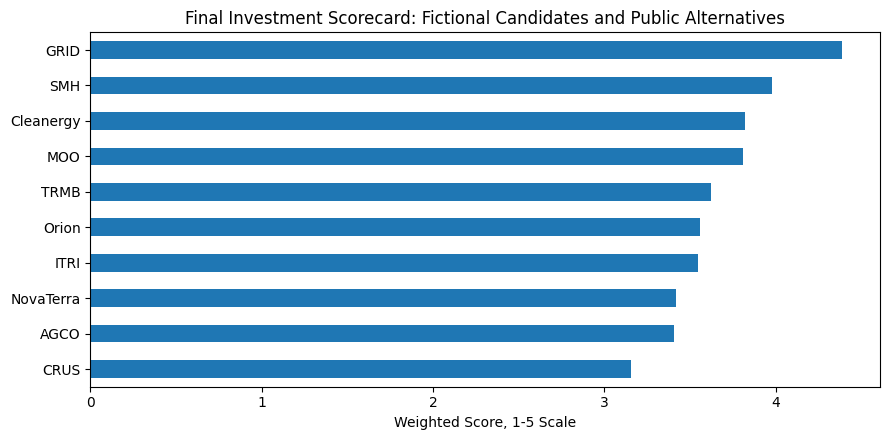

Saved chart to: C:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\charts\04_final_scorecard_all_assets.png


In [10]:
# ============================================================
# Visualize final scorecard ranking
# ============================================================

plot_data = final_scorecard.sort_values("Total Score", ascending=True)["Total Score"]

ax = plot_data.plot(kind="barh", figsize=(9, max(4, 0.45 * len(plot_data))))
ax.set_title("Final Investment Scorecard: Fictional Candidates and Public Alternatives")
ax.set_xlabel("Weighted Score, 1-5 Scale")
ax.set_ylabel("")
plt.tight_layout()

chart_path = OUTPUT_CHARTS / "04_final_scorecard_all_assets.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved chart to:", chart_path)


## 7. Portfolio-impact diagnostics

The final scorecard uses standalone quant metrics so that all public alternatives from notebook 02 can be included consistently. However, notebook 03's incremental portfolio impact remains important for interpretation.

For public stock alternatives not included in notebook 03, the incremental portfolio-impact table will not contain a row unless notebook 03 is expanded to test them as explicit portfolio scenarios.


In [11]:
# ============================================================
# Attach portfolio-impact diagnostics from notebook 03 where available
# ============================================================

impact = scenario_incremental_impact.copy()
impact.columns = impact.columns.astype(str).str.strip()

# Notebook 03 may export either "Asset Added" or "Candidate Added".
if "Asset Added" not in impact.columns:
    if "Candidate Added" in impact.columns:
        impact = impact.rename(columns={"Candidate Added": "Asset Added"})
    else:
        raise ValueError(
            "Expected 'Asset Added' or 'Candidate Added' column in "
            "03_scenario_incremental_portfolio_impact.csv. "
            f"Available columns: {list(impact.columns)}"
        )

impact["Asset Added"] = impact["Asset Added"].astype(str).str.strip()
impact = impact.set_index("Asset Added")

impact_cols = [
    c for c in [
        "Asset Type",
        "Change in Annualized Return",
        "Change in Annualized Volatility",
        "Change in Sharpe Ratio",
        "Change in Max Drawdown",
        "Drawdown Impact",
    ]
    if c in impact.columns
]

portfolio_impact_view = final_scorecard.join(impact[impact_cols], how="left")

print("Portfolio-impact diagnostics for ranked assets")
display(portfolio_impact_view.round(4))

missing_impact_assets = [asset for asset in UNIVERSE if asset not in impact.index]
if missing_impact_assets:
    print("\nAssets without notebook 03 incremental portfolio-impact scenario:", missing_impact_assets)
    print("This is acceptable for the final scorecard, but should be disclosed if one of these assets ranks highly.")


Portfolio-impact diagnostics for ranked assets


,Type,Theme,Primary ETF Benchmark,Portfolio Fit,Business Quality,Growth,Risk-Adjusted Performance,Downside Risk,EDEN Compliance,Q&A Defensibility,Total Score,Rank,Asset Type,Change in Annualized Return,Change in Annualized Volatility,Change in Sharpe Ratio,Change in Max Drawdown,Drawdown Impact
Ticker,,,,,,,,,,,,,,,,,,
GRID,ETF Alternative,Smart Grid / Energy Storage,GRID,4.5984,4.5,3.5,4.2,4.6,5.0,4.5,4.3896,1,Public Alternative ETF,0.0102,0.0010,0.0511,-0.0084,Worsens
SMH,ETF Alternative,Semiconductors / Edge AI,SMH,2.5058,4.5,4.0,5.0,4.0,5.0,4.0,3.9764,2,Public Alternative ETF,0.0287,0.0080,0.1227,0.0036,Improves
Cleanergy,Fictional Candidate,Smart Grid / Energy Storage,GRID,4.7705,4.0,4.0,2.2,2.0,5.0,4.0,3.8226,3,Fictional Candidate,-0.0017,-0.0144,0.0411,-0.0540,Worsens
MOO,ETF Alternative,Precision Agriculture / AgTech,MOO,3.9450,4.0,2.5,3.0,5.0,5.0,4.0,3.8113,4,Public Alternative ETF,-0.0113,-0.0048,-0.0464,-0.0008,Worsens
TRMB,Stock Alternative,Precision Agriculture / AgTech,MOO,4.0517,4.0,3.5,2.6,3.2,4.0,3.5,3.6229,5,NaN,NaN,NaN,NaN,NaN,NaN
Orion,Fictional Candidate,Semiconductors / Edge AI,SMH,2.4828,3.5,4.5,4.6,2.0,5.0,3.5,3.5607,6,Fictional Candidate,0.0536,0.0292,0.1664,-0.0252,Worsens
ITRI,Stock Alternative,Smart Grid / Energy Storage,GRID,4.5984,4.0,3.5,1.8,2.0,4.0,4.0,3.5446,7,NaN,NaN,NaN,NaN,NaN,NaN
NovaTerra,Fictional Candidate,Precision Agriculture / AgTech,MOO,4.3327,3.5,3.5,1.4,3.0,4.5,3.0,3.4182,8,Fictional Candidate,0.0064,-0.0151,0.0911,0.0133,Improves
AGCO,Stock Alternative,Precision Agriculture / AgTech,MOO,3.7052,3.5,2.5,3.4,3.2,4.0,3.5,3.4063,9,NaN,NaN,NaN,NaN,NaN,NaN



Assets without notebook 03 incremental portfolio-impact scenario: ['CRUS', 'ITRI', 'TRMB', 'AGCO']
This is acceptable for the final scorecard, but should be disclosed if one of these assets ranks highly.


## 8. Sensitivity analysis

This section tests whether the recommendation is stable when the committee emphasizes different priorities.

The key question is not only **who ranks first**, but whether the same name remains near the top under reasonable alternative assumptions.


In [12]:
# ============================================================
# Sensitivity analysis
# ============================================================
# The objective is to test whether the final recommendation is
# stable under different reasonable weighting assumptions.
#
# Each scenario changes the importance assigned to the scorecard
# components but keeps all component scores unchanged.
# ============================================================

sensitivity_weight_scenarios = {
    "Base Case": {
        "Portfolio Fit": 0.25,
        "Business Quality": 0.20,
        "Growth": 0.15,
        "Risk-Adjusted Performance": 0.15,
        "Downside Risk": 0.10,
        "EDEN Compliance": 0.10,
        "Q&A Defensibility": 0.05,
    },
    "Downside-Control Tilt": {
        "Portfolio Fit": 0.20,
        "Business Quality": 0.20,
        "Growth": 0.10,
        "Risk-Adjusted Performance": 0.15,
        "Downside Risk": 0.20,
        "EDEN Compliance": 0.10,
        "Q&A Defensibility": 0.05,
    },
    "Portfolio-Fit Tilt": {
        "Portfolio Fit": 0.35,
        "Business Quality": 0.15,
        "Growth": 0.10,
        "Risk-Adjusted Performance": 0.10,
        "Downside Risk": 0.10,
        "EDEN Compliance": 0.10,
        "Q&A Defensibility": 0.10,
    },
    "Quant-Performance Tilt": {
        "Portfolio Fit": 0.15,
        "Business Quality": 0.15,
        "Growth": 0.15,
        "Risk-Adjusted Performance": 0.25,
        "Downside Risk": 0.15,
        "EDEN Compliance": 0.10,
        "Q&A Defensibility": 0.05,
    },
}

# Convert to a DataFrame: rows = scenarios, columns = scorecard components.
sensitivity_weights_df = pd.DataFrame(sensitivity_weight_scenarios).T

# Ensure column order matches the component score table.
sensitivity_weights_df = sensitivity_weights_df.reindex(columns=component_scores.columns)

# Validate that all required components are present.
if sensitivity_weights_df.isna().any().any():
    missing_weights = (
        sensitivity_weights_df
        .isna()
        .stack()
        .loc[lambda s: s]
        .reset_index()
    )
    missing_weights.columns = ["Scenario", "Component", "Missing"]

    print("Missing scenario weights detected:")
    display(missing_weights[["Scenario", "Component"]])

    raise ValueError(
        "Sensitivity weights are missing for one or more scorecard components."
    )

# Normalize each scenario defensively so each row sums to 1.
sensitivity_weights_df = sensitivity_weights_df.div(
    sensitivity_weights_df.sum(axis=1),
    axis=0
)

print("Sensitivity scenario weights")
display((sensitivity_weights_df * 100).round(1))


# ============================================================
# Calculate sensitivity scores
# ============================================================

sensitivity_scores = pd.DataFrame(index=component_scores.index)

for scenario_name, scenario_weights in sensitivity_weights_df.iterrows():
    scenario_score = (
        component_scores
        .mul(scenario_weights, axis=1)
        .sum(axis=1)
    )

    sensitivity_scores[scenario_name] = scenario_score

# Rank each scenario independently.
sensitivity_ranks = sensitivity_scores.rank(
    ascending=False,
    method="min"
).astype(int)

# Combine scores and ranks in one clean table.
sensitivity_summary = sensitivity_scores.copy()

for scenario_name in sensitivity_scores.columns:
    sensitivity_summary[f"{scenario_name} Rank"] = sensitivity_ranks[scenario_name]

# Sort by base-case score.
sensitivity_summary = sensitivity_summary.sort_values(
    "Base Case",
    ascending=False
)

print("Sensitivity analysis: total scores")
display(sensitivity_scores.sort_values("Base Case", ascending=False).round(2))

print("Sensitivity analysis: scores and ranks")
display(sensitivity_summary.round(2))

# Long-format table for decision helper and exports.
sensitivity_df = (
    sensitivity_scores
    .reset_index()
    .rename(columns={"index": "Ticker"})
    .melt(id_vars="Ticker", var_name="Scenario", value_name="Score")
)

sensitivity_df["Rank"] = sensitivity_df.groupby("Scenario")["Score"].rank(
    ascending=False,
    method="min"
).astype(int)


Sensitivity scenario weights


,Portfolio Fit,Business Quality,Growth,Risk-Adjusted Performance,Downside Risk,EDEN Compliance,Q&A Defensibility
Base Case,25.0,20.0,15.0,15.0,10.0,10.0,5.0
Downside-Control Tilt,20.0,20.0,10.0,15.0,20.0,10.0,5.0
Portfolio-Fit Tilt,35.0,15.0,10.0,10.0,10.0,10.0,10.0
Quant-Performance Tilt,15.0,15.0,15.0,25.0,15.0,10.0,5.0


Sensitivity analysis: total scores


,Base Case,Downside-Control Tilt,Portfolio-Fit Tilt,Quant-Performance Tilt
GRID,4.39,4.44,4.46,4.35
SMH,3.98,4.05,3.75,4.20
Cleanergy,3.82,3.58,3.99,3.47
MOO,3.81,3.99,3.93,3.77
TRMB,3.62,3.57,3.70,3.44
Orion,3.56,3.41,3.35,3.70
ITRI,3.54,3.34,3.74,3.16
NovaTerra,3.42,3.33,3.58,3.10
AGCO,3.41,3.42,3.48,3.36
CRUS,3.15,3.19,3.02,3.28


Sensitivity analysis: scores and ranks


,Base Case,Downside-Control Tilt,Portfolio-Fit Tilt,Quant-Performance Tilt,Base Case Rank,Downside-Control Tilt Rank,Portfolio-Fit Tilt Rank,Quant-Performance Tilt Rank
GRID,4.39,4.44,4.46,4.35,1,1,1,1
SMH,3.98,4.05,3.75,4.20,2,2,4,2
Cleanergy,3.82,3.58,3.99,3.47,3,4,2,5
MOO,3.81,3.99,3.93,3.77,4,3,3,3
TRMB,3.62,3.57,3.70,3.44,5,5,6,6
Orion,3.56,3.41,3.35,3.70,6,7,9,4
ITRI,3.54,3.34,3.74,3.16,7,8,5,9
NovaTerra,3.42,3.33,3.58,3.10,8,9,7,10
AGCO,3.41,3.42,3.48,3.36,9,6,8,7
CRUS,3.15,3.19,3.02,3.28,10,10,10,8


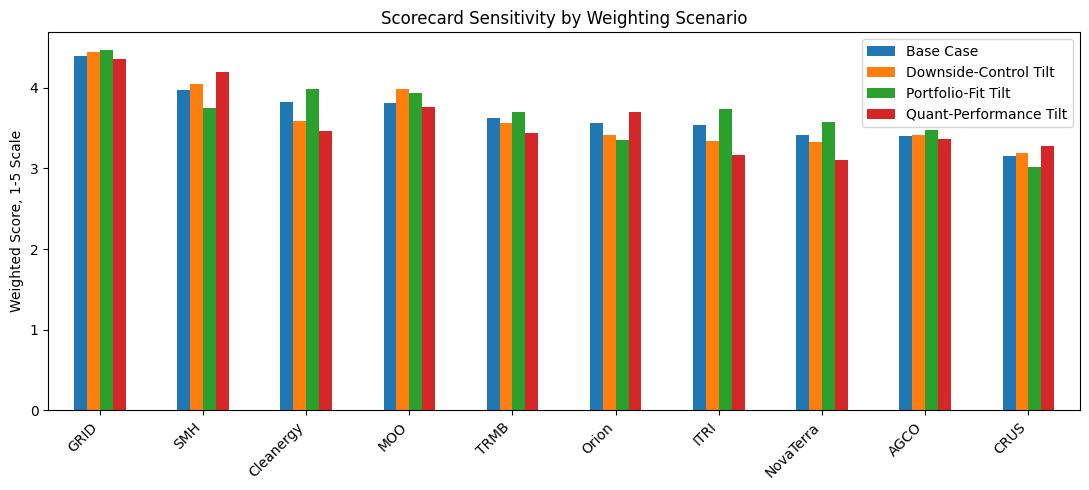

Saved chart to: C:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\charts\04_scorecard_sensitivity_all_assets.png


In [ ]:
# ============================================================
# Sensitivity chart
# ============================================================

ax = sensitivity_scores.loc[final_scorecard.index].plot(kind="bar", figsize=(11, 5))
ax.set_title("Scorecard Sensitivity by Weighting Scenario")
ax.set_ylabel("Weighted Score, 1-5 Scale")
ax.set_xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

sensitivity_chart_path = OUTPUT_CHARTS / "04_scorecard_sensitivity_all_assets.png"
plt.savefig(sensitivity_chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved chart to:", sensitivity_chart_path)

## 9. Decision helper

This block translates the ranking into the correct investment-committee framing:

- If a fictional candidate ranks first, the recommendation is to buy that candidate and reject the others.
- If a public stock or ETF ranks first, the recommendation is to reject all three fictional candidates and recommend the public alternative, subject to EDEN rule confirmation.
- If the top ranked asset is fragile under sensitivity analysis, the presentation should frame the result as a judgment call rather than a mechanical output.


In [ ]:
# ============================================================
# Decision helper
# ============================================================

top_asset = final_scorecard.index[0]
top_type = final_scorecard.loc[top_asset, "Type"] if "Type" in final_scorecard.columns else "Unknown"
base_score = final_scorecard.loc[top_asset, "Total Score"]

fictional_assets_in_scorecard = [x for x in FICTIONAL_CANDIDATES if x in final_scorecard.index]
fictional_ranking = final_scorecard.loc[fictional_assets_in_scorecard].copy()
fictional_ranking = fictional_ranking.sort_values("Total Score", ascending=False)
best_fictional = fictional_ranking.index[0] if not fictional_ranking.empty else "Not available"

if "sensitivity_df" not in globals():
    sensitivity_df = (
        sensitivity_scores
        .reset_index()
        .rename(columns={"index": "Ticker"})
        .melt(id_vars="Ticker", var_name="Scenario", value_name="Score")
    )

winner_counts = (
    sensitivity_df
    .loc[sensitivity_df.groupby("Scenario")["Score"].idxmax(), "Ticker"]
    .value_counts()
)

print("Top-ranked asset:", top_asset)
print("Type:", top_type)
print("Base-case score:", round(base_score, 2))
print("Best fictional candidate:", best_fictional)
print("\nSensitivity winner counts:")
print(winner_counts)

if top_asset in FICTIONAL_CANDIDATES:
    recommendation_frame = (
        f"Base-case recommendation: invest the €5,000 allocation in {top_asset}. "
        "The public alternatives should be discussed as benchmarks/reality checks rather than the primary recommendation."
    )
else:
    recommendation_frame = (
        f"Base-case recommendation: reject all three fictional candidates and recommend {top_asset}, "
        "subject to final EDEN compliance checks. The presentation must explicitly explain why the public alternative offers a cleaner risk/reward or portfolio-construction case."
    )

print("\n" + recommendation_frame)

decision_summary = pd.DataFrame({
    "Item": [
        "Base-case top asset",
        "Base-case top asset type",
        "Best fictional candidate",
        "Most common sensitivity winner",
        "Interpretation",
    ],
    "Result": [
        top_asset,
        top_type,
        best_fictional,
        winner_counts.index[0] if not winner_counts.empty else "Not available",
        recommendation_frame,
    ],
})

display(decision_summary)


Top-ranked asset: GRID
Type: ETF Alternative
Base-case score: 4.39
Best fictional candidate: Cleanergy

Sensitivity winner counts:
Ticker
GRID    4
Name: count, dtype: int64

Base-case recommendation: reject all three fictional candidates and recommend GRID, subject to final EDEN compliance checks. The presentation must explicitly explain why the public alternative offers a cleaner risk/reward or portfolio-construction case.


,Item,Result
0,Base-case top asset,GRID
1,Base-case top asset type,ETF Alternative
2,Best fictional candidate,Cleanergy
3,Most common sensitivity winner,GRID
4,Interpretation,Base-case recommendation: reject all three fic...


## 10. Risk register and Q&A preparation

This table should be used directly for the investment-committee Q&A. Add more rows if the final top-ranked asset changes after sensitivity review.


In [ ]:
# ============================================================
# Risk register
# ============================================================

risk_register_rows = [
    {
        "Asset": "Orion",
        "Main Risk": "Duplicates existing ASML semiconductor / AI-capex exposure.",
        "Evidence / Context": "Strong growth profile, but portfolio already has semiconductor exposure through ASML.",
        "Mitigation / Q&A Response": "Only recommend Orion if its standalone quant performance clearly compensates for concentration and if edge inference is framed as differentiated from semiconductor equipment exposure.",
    },
    {
        "Asset": "Cleanergy",
        "Main Risk": "High volatility/drawdown and third-party battery-cell dependence.",
        "Evidence / Context": "Strongest portfolio-gap candidate: energy storage, grid infrastructure, recurring lease/ARR model.",
        "Mitigation / Q&A Response": "Frame as intentional Learn -> Stocks risk; compare against GRID to show whether single-name risk is compensated.",
    },
    {
        "Asset": "NovaTerra",
        "Main Risk": "Portfolio-fit story may be less urgent than energy infrastructure; revenue per acre weakens pricing-power narrative.",
        "Evidence / Context": "High subscription revenue and geographic diversification, but less direct current-portfolio gap.",
        "Mitigation / Q&A Response": "Use only if quant evidence and diversification benefit clearly dominate Cleanergy/GRID.",
    },
    {
        "Asset": "SMH",
        "Main Risk": "Clean, diversified exposure but duplicates ASML/semiconductor theme.",
        "Evidence / Context": "Useful public benchmark for Orion.",
        "Mitigation / Q&A Response": "Reject if objective is to fill a portfolio gap rather than add more semiconductor beta.",
    },
    {
        "Asset": "GRID",
        "Main Risk": "ETF may dilute upside versus a high-conviction single stock.",
        "Evidence / Context": "Clean public alternative to Cleanergy's smart-grid/storage-infrastructure thesis.",
        "Mitigation / Q&A Response": "Recommend over Cleanergy if downside control and Q&A defensibility matter more than single-name upside.",
    },
    {
        "Asset": "MOO",
        "Main Risk": "Broader agribusiness exposure is less pure than NovaTerra's AI/agtech thesis.",
        "Evidence / Context": "Useful public benchmark for NovaTerra.",
        "Mitigation / Q&A Response": "Use as a reality check; not automatically superior unless risk-adjusted performance and downside protection dominate.",
    },
]

risk_register = pd.DataFrame(risk_register_rows)
print("Risk register")
display(risk_register)


Risk register


,Asset,Main Risk,Evidence / Context,Mitigation / Q&A Response
0,Orion,Duplicates existing ASML semiconductor / AI-ca...,"Strong growth profile, but portfolio already h...",Only recommend Orion if its standalone quant p...
1,Cleanergy,High volatility/drawdown and third-party batte...,Strongest portfolio-gap candidate: energy stor...,Frame as intentional Learn -> Stocks risk; com...
2,NovaTerra,Portfolio-fit story may be less urgent than en...,High subscription revenue and geographic diver...,Use only if quant evidence and diversification...
3,SMH,"Clean, diversified exposure but duplicates ASM...",Useful public benchmark for Orion.,Reject if objective is to fill a portfolio gap...
4,GRID,ETF may dilute upside versus a high-conviction...,Clean public alternative to Cleanergy's smart-...,Recommend over Cleanergy if downside control a...
5,MOO,Broader agribusiness exposure is less pure tha...,Useful public benchmark for NovaTerra.,Use as a reality check; not automatically supe...


## 11. Export final outputs

These exports should feed the slides and appendix.


In [ ]:
# ============================================================
# Export notebook 04 outputs
# ============================================================

# AHP weights.
portfolio_fit_weights.reset_index().rename(columns={"index": "Category"}).to_csv(
    OUTPUT_TABLES / "04_ahp_portfolio_fit_weights.csv",
    index=False,
)

# Optional AHP matrix.
if "ahp_matrix_df" in globals() and not ahp_matrix_df.empty:
    ahp_matrix_df.to_csv(OUTPUT_TABLES / "04_ahp_pairwise_matrix.csv")

portfolio_fit_category_scores.to_csv(OUTPUT_TABLES / "04_portfolio_fit_category_scores_all_assets.csv")
portfolio_fit_model.to_csv(OUTPUT_TABLES / "04_portfolio_fit_model_all_assets.csv")
component_scores.to_csv(OUTPUT_TABLES / "04_component_scores_all_assets.csv")
weighted_components.to_csv(OUTPUT_TABLES / "04_weighted_components_all_assets.csv")
final_scorecard.to_csv(OUTPUT_TABLES / "04_final_scorecard_all_assets.csv")
portfolio_impact_view.to_csv(OUTPUT_TABLES / "04_final_scorecard_with_portfolio_impact.csv")
sensitivity_df.to_csv(OUTPUT_TABLES / "04_sensitivity_analysis_long.csv", index=False)
sensitivity_scores.to_csv(OUTPUT_TABLES / "04_sensitivity_scores_all_assets.csv")
sensitivity_ranks.to_csv(OUTPUT_TABLES / "04_sensitivity_ranks_all_assets.csv")
decision_summary.to_csv(OUTPUT_TABLES / "04_decision_summary.csv", index=False)
risk_register.to_csv(OUTPUT_TABLES / "04_risk_register.csv", index=False)

print("Notebook 04 completed.")
print("\nKey exports:")
for filename in [
    "04_final_scorecard_all_assets.csv",
    "04_final_scorecard_with_portfolio_impact.csv",
    "04_sensitivity_scores_all_assets.csv",
    "04_decision_summary.csv",
    "04_risk_register.csv",
]:
    print(OUTPUT_TABLES / filename)

print("\nKey charts:")
print(OUTPUT_CHARTS / "04_final_scorecard_all_assets.png")
print(OUTPUT_CHARTS / "04_scorecard_sensitivity_all_assets.png")


Notebook 04 completed.

Key exports:
C:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\tables\04_final_scorecard_all_assets.csv
C:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\tables\04_final_scorecard_with_portfolio_impact.csv
C:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\tables\04_sensitivity_scores_all_assets.csv
C:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\tables\04_decision_summary.csv
C:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\tables\04_risk_register.csv

Key charts:
C:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\charts\04_final_scorecard_all_assets.png
C:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\charts\04_scorecard_sensitivity_all_assets.png
